### STUDENT HEALTH ANALYSIS PROJECT

In [1]:
## General Purpose
import warnings
from itertools import combinations
from copy import deepcopy

import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns 
pd.set_option("display.max_columns", None)

In [2]:
df = pd.read_csv("data/train.csv")
df

,id,health_condition,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake,diet_type,stress_level,sleep_quality,physical_activity_level,smoking_alcohol,gender
0,0,unhealthy,5.22,70.6,25.66,2174.0,1326.0,19.8,1.86,veg,high,average,sedentary,yes,female
1,1,at-risk,5.53,71.3,25.84,1966.0,9891.0,49.9,1.26,non-veg,low,average,moderate,yes,other
2,2,unhealthy,5.29,75.4,24.54,2688.0,14216.0,38.1,1.60,veg,high,poor,active,yes,male
3,3,unhealthy,4.70,77.2,23.13,2630.0,7174.0,59.9,2.02,veg,high,average,active,occasional,female
4,4,at-risk,7.23,73.4,28.44,2560.0,6584.0,46.0,2.25,veg,NaN,average,sedentary,NaN,male
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
690083,690083,at-risk,6.31,69.7,24.11,2157.0,NaN,30.8,3.00,non-veg,high,poor,active,yes,female
690084,690084,at-risk,5.78,54.0,26.36,2858.0,6488.0,52.4,1.46,veg,medium,average,moderate,no,male
690085,690085,fit,7.64,85.7,21.91,2195.0,9241.0,41.3,1.57,non-veg,NaN,average,active,no,male
690086,690086,at-risk,6.74,73.0,18.73,2061.0,13366.0,56.6,2.60,balanced,NaN,average,active,yes,male


In [3]:
student_data = df.drop('id', axis=1).copy()
student_data.head(5)

,health_condition,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake,diet_type,stress_level,sleep_quality,physical_activity_level,smoking_alcohol,gender
0,unhealthy,5.22,70.6,25.66,2174.0,1326.0,19.8,1.86,veg,high,average,sedentary,yes,female
1,at-risk,5.53,71.3,25.84,1966.0,9891.0,49.9,1.26,non-veg,low,average,moderate,yes,other
2,unhealthy,5.29,75.4,24.54,2688.0,14216.0,38.1,1.60,veg,high,poor,active,yes,male
3,unhealthy,4.70,77.2,23.13,2630.0,7174.0,59.9,2.02,veg,high,average,active,occasional,female
4,at-risk,7.23,73.4,28.44,2560.0,6584.0,46.0,2.25,veg,NaN,average,sedentary,NaN,male


In [4]:
student_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 690088 entries, 0 to 690087
Data columns (total 14 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   health_condition         690088 non-null  str    
 1   sleep_duration           614089 non-null  float64
 2   heart_rate               682255 non-null  float64
 3   bmi                      676190 non-null  float64
 4   calorie_expenditure      637235 non-null  float64
 5   step_count               676172 non-null  float64
 6   exercise_duration        683187 non-null  float64
 7   water_intake             646611 non-null  float64
 8   diet_type                683187 non-null  str    
 9   stress_level             607277 non-null  str    
 10  sleep_quality            631757 non-null  str    
 11  physical_activity_level  653467 non-null  str    
 12  smoking_alcohol          661506 non-null  str    
 13  gender                   668715 non-null  str    
dtypes: float64(7), 

In [5]:
student_data.shape

(690088, 14)

In [6]:
student_data.isna().sum() / len(student_data) * 100

health_condition            0.000000
sleep_duration             11.012943
heart_rate                  1.135073
bmi                         2.013946
calorie_expenditure         7.658878
step_count                  2.016554
exercise_duration           1.000017
water_intake                6.300211
diet_type                   1.000017
stress_level               12.000064
sleep_quality               8.452690
physical_activity_level     5.306715
smoking_alcohol             4.141791
gender                      3.097141
dtype: float64

In [7]:
student_data['sleep_duration'] = student_data['sleep_duration'].interpolate()

In [8]:
most_frequent_value = student_data['stress_level'].mode()[0]
student_data['stress_level'] = student_data['stress_level'].fillna(most_frequent_value)

In [9]:
student_data['stress_level']

0           high
1            low
2           high
3           high
4         medium
           ...  
690083      high
690084    medium
690085    medium
690086    medium
690087    medium
Name: stress_level, Length: 690088, dtype: str

In [10]:
student_data = student_data.dropna()
student_data.shape

(446226, 14)

In [11]:
student_data.isna().sum() / len(student_data) * 100

health_condition           0.0
sleep_duration             0.0
heart_rate                 0.0
bmi                        0.0
calorie_expenditure        0.0
step_count                 0.0
exercise_duration          0.0
water_intake               0.0
diet_type                  0.0
stress_level               0.0
sleep_quality              0.0
physical_activity_level    0.0
smoking_alcohol            0.0
gender                     0.0
dtype: float64

##### Setting up outlier detection and cleaning 

In [12]:
# from pprint import pprint

# for col in student_data.select_dtypes(exclude=str):
#     mean = student_data[col].mean()
#     st_dev = student_data[col].std()
    
#     # Store clean floats in your dictionary
#     new_col[col] = float(mean), float(deviation)
    
#     ### Outlier definition
#     outlier_threasold =  st_dev * 3
#     print(f'--- {col} outlier ---')
#     print(outlier_threasold)
    
    
#     upper_limit = mean + outlier_threasold
#     lower_limit = mean - outlier_threasold
    
#     ## Getting outlier
#     outlier_numbers = (student_data[col] < lower_limit) | (student_data[col] > upper_limit)
#     print(f'Number of outliers found {outlier_numbers.sum()}\n')
    
# pprint(new_col)    
    

### Visualizing the outliers

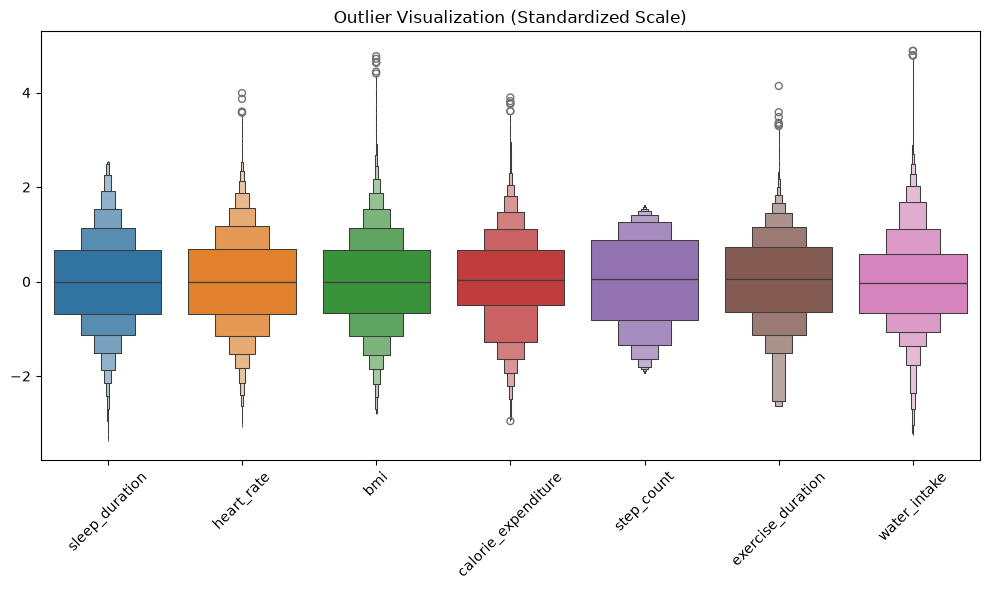

In [13]:
## Creating the boxplot
num_data = student_data.select_dtypes(exclude=str)

standardized_data = (num_data - num_data.mean() ) / num_data.std()


plt.figure(figsize=(10, 6))
sns.boxenplot(data=standardized_data)
plt.title("Outlier Visualization (Standardized Scale)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

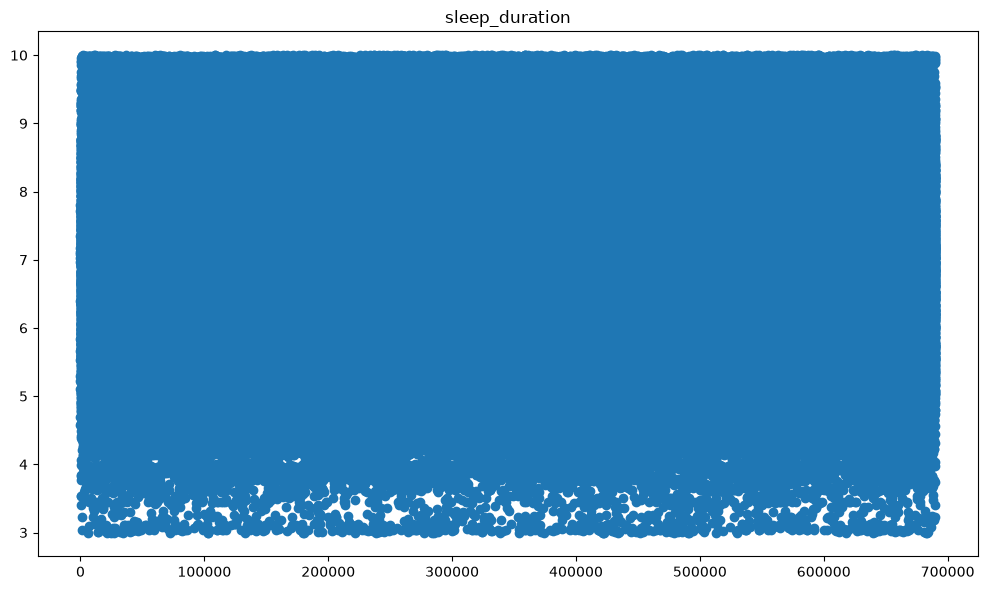

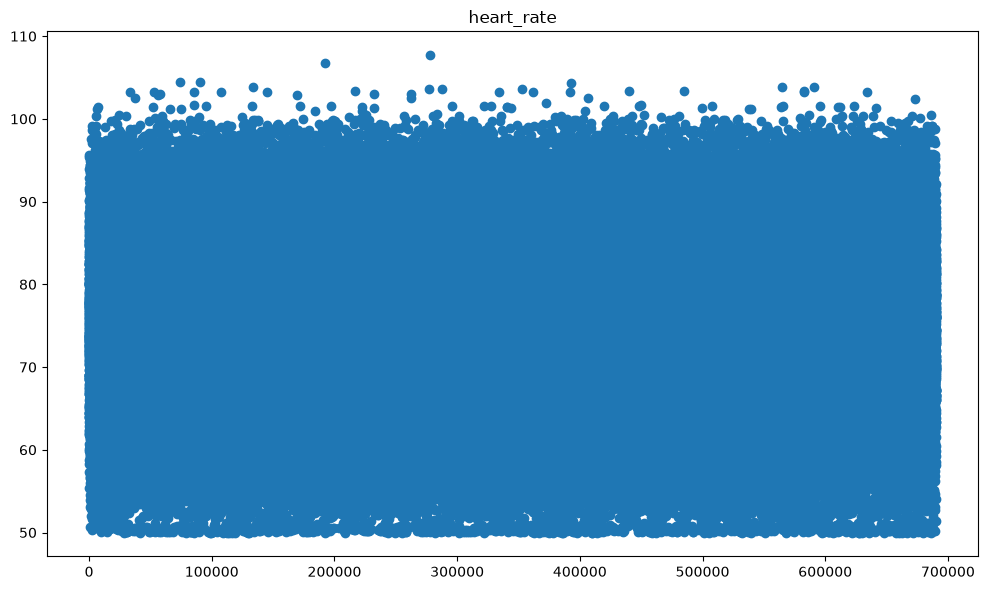

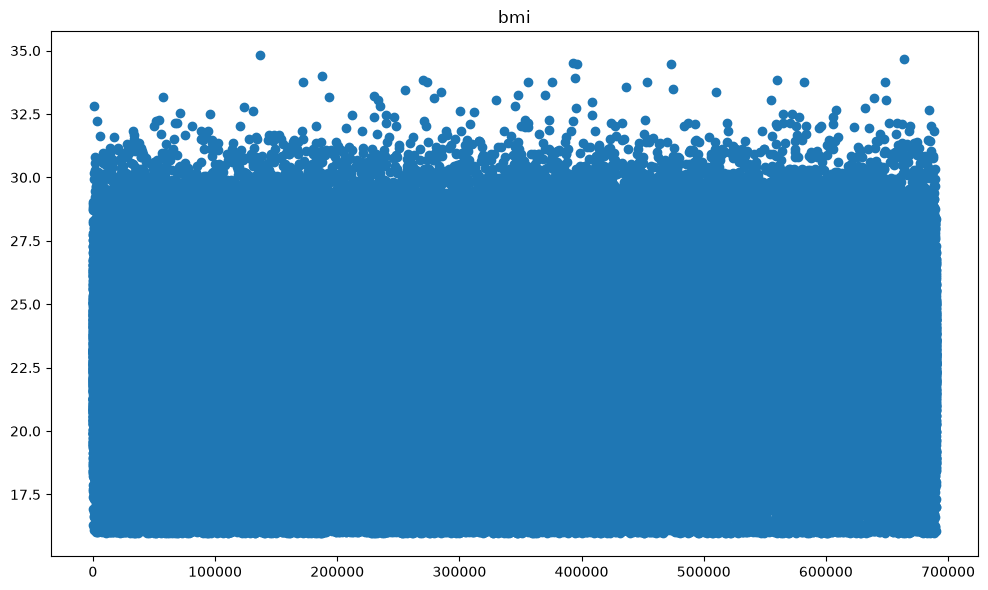

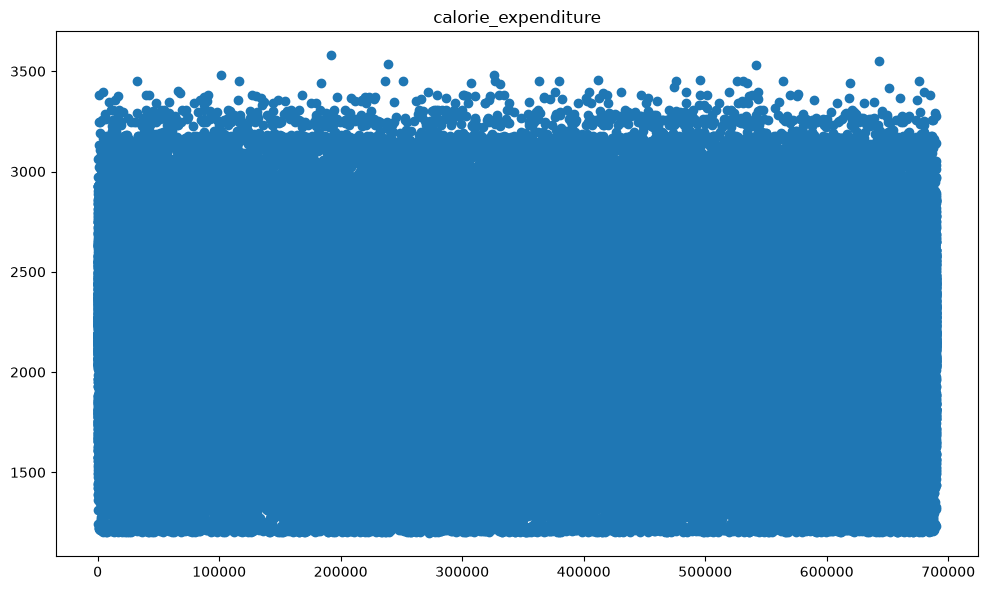

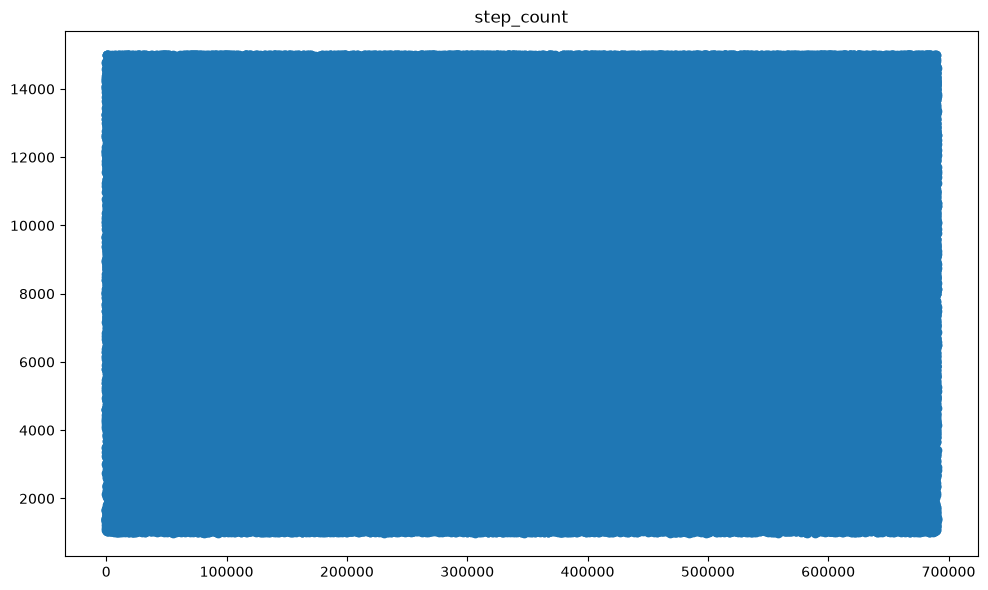

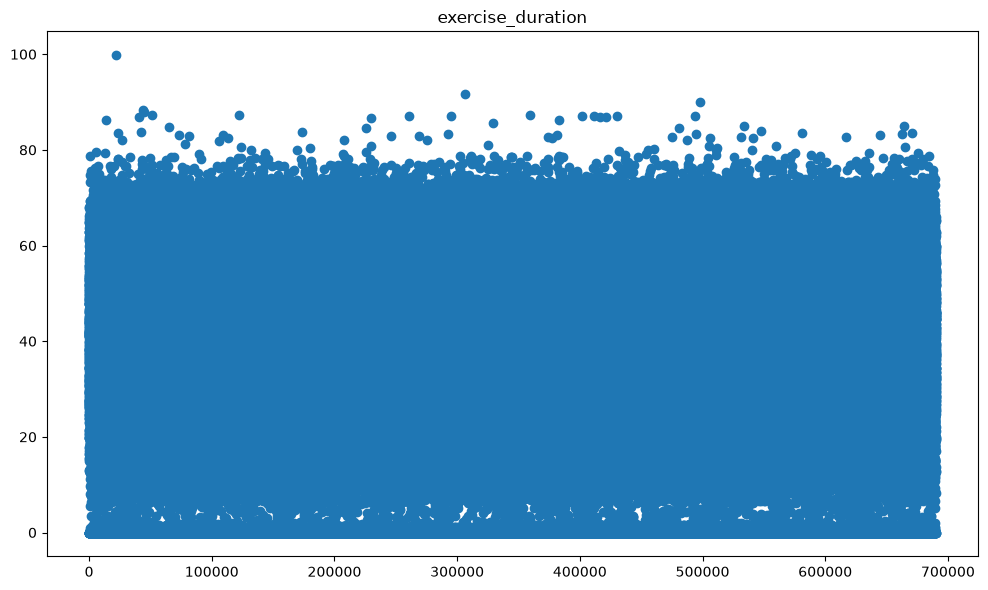

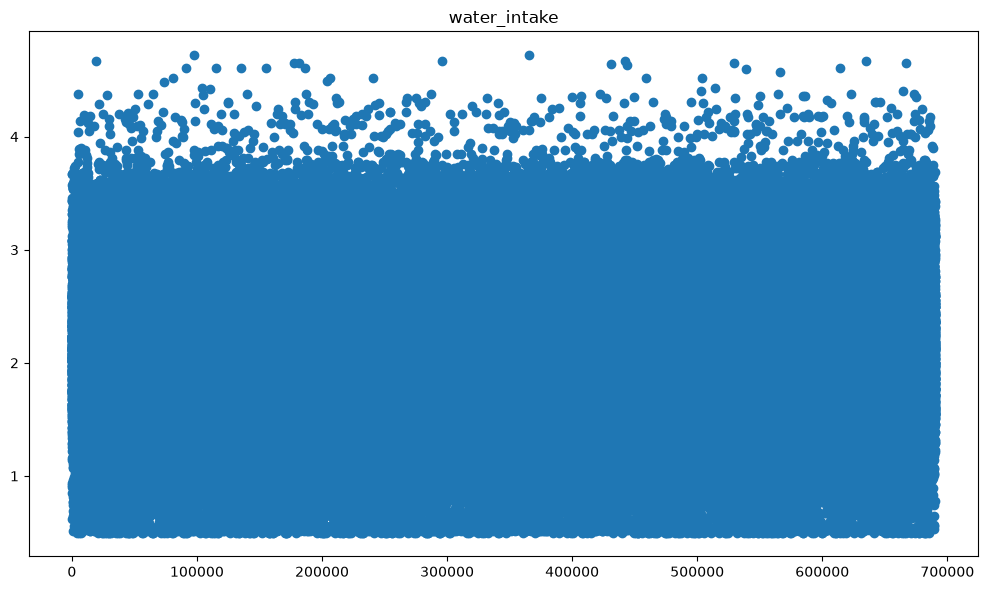

In [14]:
# Creating scatterplot

for col in num_data:
    plt.figure(figsize=(10, 6))
    plt.scatter(y=num_data[col], x=num_data.index)
    plt.title(f"{col}")
    plt.tight_layout()
    plt.show()

In [15]:

def outlier_remover(df, threshold:int):
    '''
    This calculates the stats of the data and remove the oulier
    using 3 standard deviation above and below the mean of the data
    '''
    data_outlier = {}
    data_stats = {}
    all_outlier_row = set()
    for col in df:
        
        ## Calculating the stats
        data_mean = df[col].mean()
        data_std = df[col].std()
        
        data_stats[col] = float(data_mean), float(data_std)
        
        ## Calculating outlier threasold
        outlier_threasold = data_std * threshold
        
        ## Calculating the limit
        upper_limit = data_mean + outlier_threasold
        lower_limit = data_mean - outlier_threasold
        
        is_outlier = (df[col] < lower_limit) | (df[col] > upper_limit)
        outlier_row = df[is_outlier].index
        
        data_outlier[col] = float(is_outlier.sum())
        
        print("-------------------------------")
        print(outlier_row)
        
        all_outlier_row.update(outlier_row)
        
    ## Cleaning the dataset
    cleaned_data = df.drop(index=all_outlier_row)
    
    return cleaned_data, data_stats, data_outlier

In [16]:
cleaned_data, outlier_data, is_outlier =  outlier_remover(num_data, 2.5)
outlier_data

-------------------------------
Index([   249,    265,    325,    385,    465,    551,    662,    684,   1016,
         1126,
       ...
       688791, 688889, 688970, 689246, 689480, 689493, 689512, 689542, 689694,
       689977],
      dtype='int64', length=5915)
-------------------------------
Index([   313,    438,    572,    799,    894,   1386,   1443,   1572,   1587,
         1945,
       ...
       688983, 688999, 689309, 689454, 689457, 689489, 689536, 689617, 689906,
       690084],
      dtype='int64', length=4694)
-------------------------------
Index([   248,    527,    588,    688,    990,    999,   1152,   1252,   1620,
         1682,
       ...
       688591, 688632, 688999, 689000, 689035, 689089, 689127, 689329, 689637,
       689957],
      dtype='int64', length=5894)
-------------------------------
Index([    27,     66,   1025,   1098,   1106,   1222,   1256,   1275,   1858,
         1870,
       ...
       688902, 689009, 689019, 689145, 689378, 689569, 689757, 68

{'sleep_duration': (6.983128283276486, 1.1829870456557159),
 'heart_rate': (75.09414182499451, 8.171941130569502),
 'bmi': (22.979137858394623, 2.4820149698933807),
 'calorie_expenditure': (2226.104610668137, 347.3989176175487),
 'step_count': (8615.79632069848, 3932.0740059660875),
 'exercise_duration': (38.744104780985424, 14.744100053402853),
 'water_intake': (2.1881976621711865, 0.5184111687494221)}

In [17]:
is_outlier

{'sleep_duration': 5915.0,
 'heart_rate': 4694.0,
 'bmi': 5894.0,
 'calorie_expenditure': 5429.0,
 'step_count': 0.0,
 'exercise_duration': 14558.0,
 'water_intake': 8700.0}

In [18]:
cleaned_data

,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake
0,5.22,70.6,25.66,2174.0,1326.0,19.8,1.86
1,5.53,71.3,25.84,1966.0,9891.0,49.9,1.26
2,5.29,75.4,24.54,2688.0,14216.0,38.1,1.60
3,4.70,77.2,23.13,2630.0,7174.0,59.9,2.02
5,5.11,82.8,24.43,2290.0,2134.0,29.2,2.02
...,...,...,...,...,...,...,...
690080,6.20,58.2,25.78,1490.0,1441.0,12.8,1.81
690081,7.02,79.2,23.35,2314.0,8881.0,45.3,1.77
690085,7.64,85.7,21.91,2195.0,9241.0,41.3,1.57
690086,6.74,73.0,18.73,2061.0,13366.0,56.6,2.60


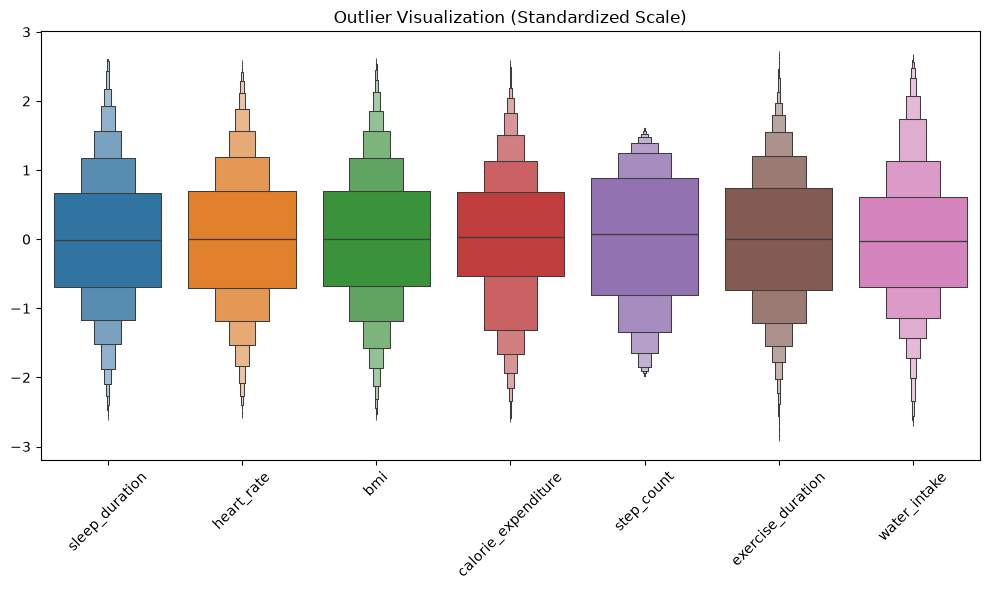

In [19]:
## Checking if outliers are gone 

## Standardizing data
standardized_cleaned_data = (cleaned_data - cleaned_data.mean()) / cleaned_data.std()

plt.figure(figsize=(10, 6))
sns.boxenplot(data=standardized_cleaned_data.dropna())
plt.title("Outlier Visualization (Standardized Scale)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [20]:
# Check how many outliers remain
standardized = (cleaned_data - cleaned_data.mean()) / cleaned_data.std()
beyond_3std = (standardized.abs() > 3).sum()
print(beyond_3std)


sleep_duration         0
heart_rate             0
bmi                    0
calorie_expenditure    0
step_count             0
exercise_duration      0
water_intake           0
dtype: int64


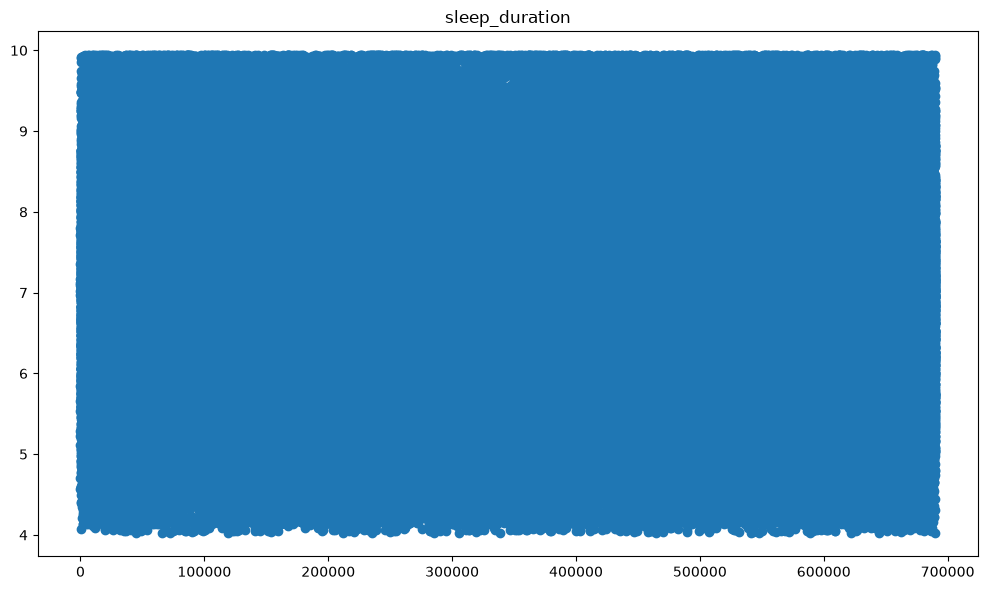

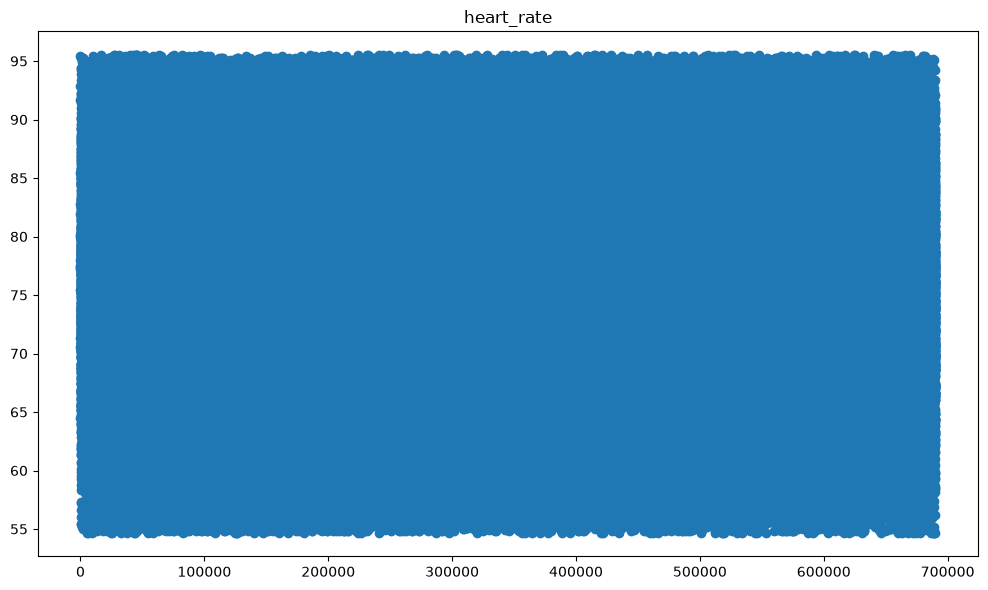

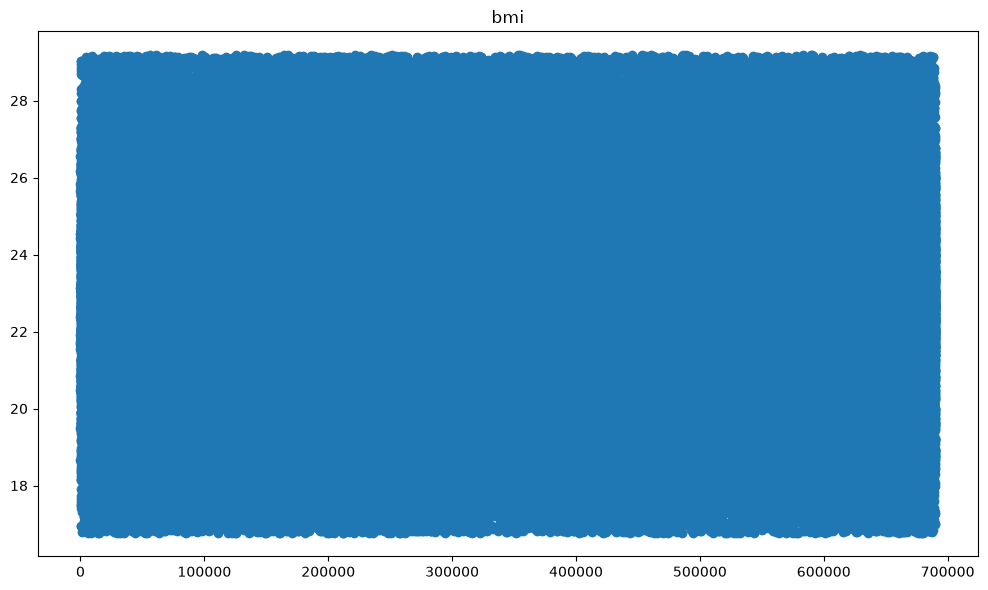

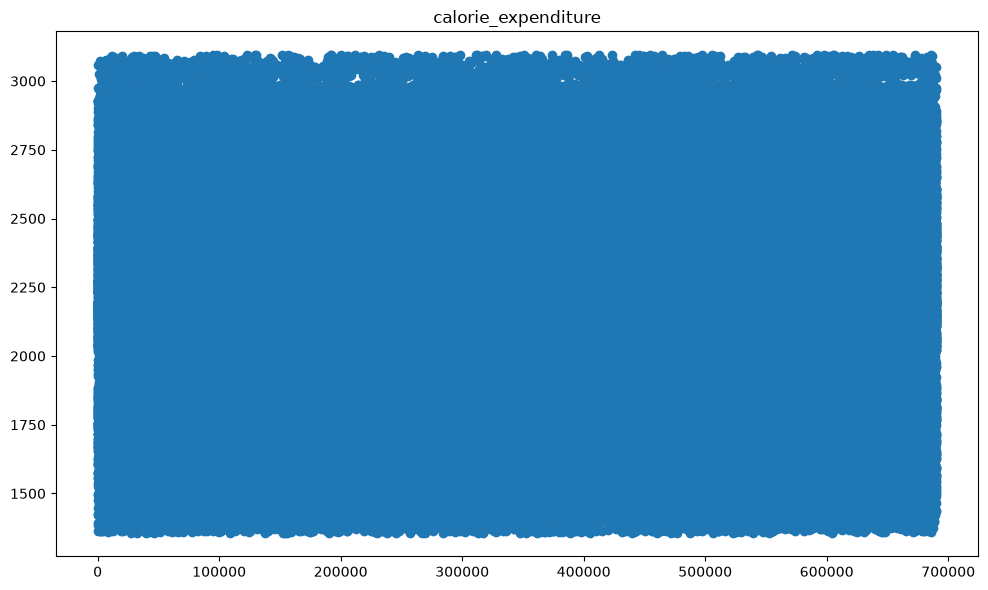

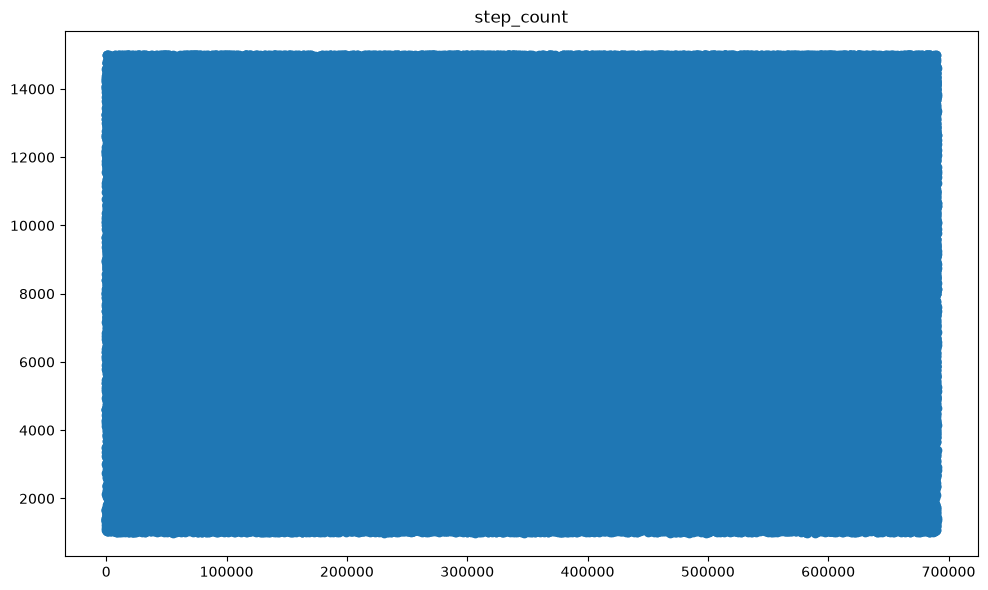

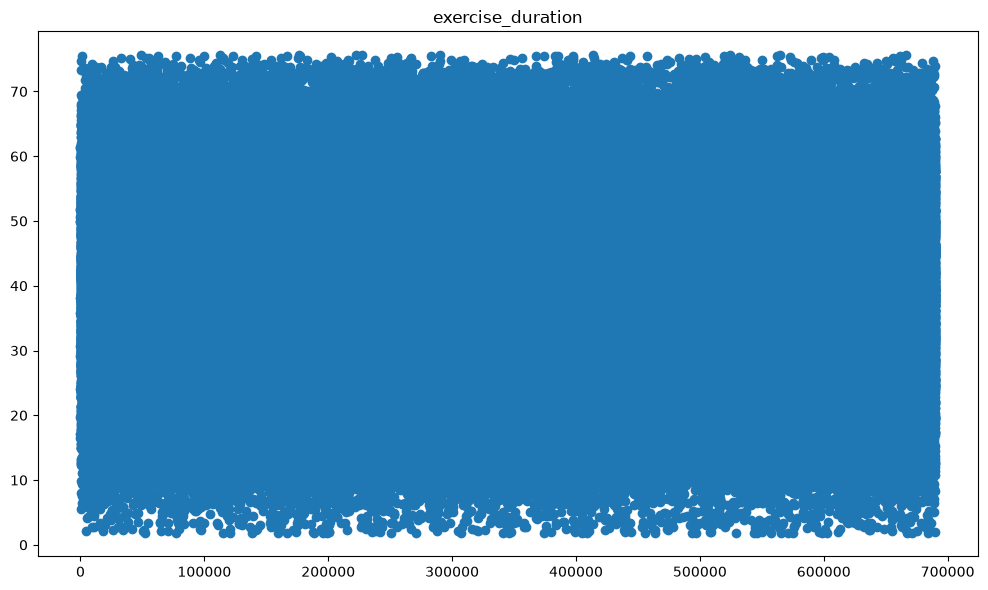

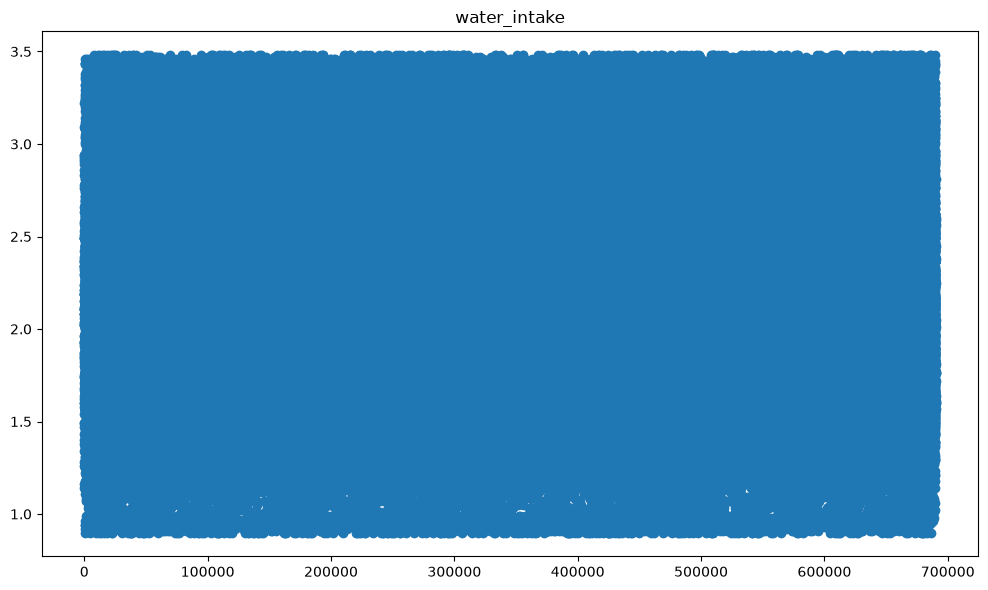

In [21]:

for col in cleaned_data:
    plt.figure(figsize=(10, 6))
    plt.scatter(x=cleaned_data.index, y=cleaned_data[col])
    plt.title(f"{col}")
    plt.tight_layout()
    plt.show()

In [22]:
# Check final row/column dimensions
print("Dataset Dimensions:", cleaned_data.shape)

Dataset Dimensions: (403227, 7)


In [23]:
# Check for missing values and structural types
cleaned_data.info()

<class 'pandas.DataFrame'>
Index: 403227 entries, 0 to 690087
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   sleep_duration       403227 non-null  float64
 1   heart_rate           403227 non-null  float64
 2   bmi                  403227 non-null  float64
 3   calorie_expenditure  403227 non-null  float64
 4   step_count           403227 non-null  float64
 5   exercise_duration    403227 non-null  float64
 6   water_intake         403227 non-null  float64
dtypes: float64(7)
memory usage: 24.6 MB


In [24]:
print(f"Dataset before removing null values: {df.shape}")
print(f"Dataset after removing null values: {student_data.shape}")
print(f"Dataset after removing null values on numerical data: {cleaned_data.shape}")

Dataset before removing null values: (690088, 15)
Dataset after removing null values: (446226, 14)
Dataset after removing null values on numerical data: (403227, 7)


In [25]:
print((cleaned_data.shape[0] / student_data.shape[0]) * 100 )
print((student_data.shape[0]- cleaned_data.shape[0]) * 100 )
print("-------------percentgage reduction in data-----------")
print(f'the percentage reduction in dataset size is: {(( student_data.shape[0]- cleaned_data.shape[0]) / student_data.shape[0]) * 100}')

90.36385150125722
4299900
-------------percentgage reduction in data-----------
the percentage reduction in dataset size is: 9.63614849874279


In [26]:
# Filter the original dataset using the clean data's index
final_data = student_data.loc[cleaned_data.index]

# Verify that all columns (text + numbers) are back together
print("Dimensions:", final_data.shape)
print("Columns:", final_data.columns.tolist())


Dimensions: (403227, 14)
Columns: ['health_condition', 'sleep_duration', 'heart_rate', 'bmi', 'calorie_expenditure', 'step_count', 'exercise_duration', 'water_intake', 'diet_type', 'stress_level', 'sleep_quality', 'physical_activity_level', 'smoking_alcohol', 'gender']


### Exploratory Data Analysis

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

train = pd.read_csv('data/train.csv')

print('=== SHAPE ===')
print(train.shape)

print('\n=== DTYPES ===')
print(train.dtypes)

print('\n=== FIRST 5 ROWS ===')
print(train.head())

print('\n=== TARGET DISTRIBUTION ===')
print(train['health_condition'].value_counts())
print(train['health_condition'].value_counts(normalize=True).round(3) * 100)

print('\n=== MISSING VALUES ===')
print(train.isnull().sum())

print('\n=== BASIC STATS ===')
print(train.describe().round(2))

=== SHAPE ===
(690088, 15)

=== DTYPES ===
id                           int64
health_condition               str
sleep_duration             float64
heart_rate                 float64
bmi                        float64
calorie_expenditure        float64
step_count                 float64
exercise_duration          float64
water_intake               float64
diet_type                      str
stress_level                   str
sleep_quality                  str
physical_activity_level        str
smoking_alcohol                str
gender                         str
dtype: object

=== FIRST 5 ROWS ===
   id health_condition  sleep_duration  heart_rate    bmi  \
0   0        unhealthy            5.22        70.6  25.66   
1   1          at-risk            5.53        71.3  25.84   
2   2        unhealthy            5.29        75.4  24.54   
3   3        unhealthy            4.70        77.2  23.13   
4   4          at-risk            7.23        73.4  28.44   

   calorie_expenditure  step_

In [28]:
# Target distribution
print(train['health_condition'].value_counts())
print(train['health_condition'].value_counts(normalize=True).round(3) * 100)

# Missing values
print(train.isnull().sum())

health_condition
at-risk      592561
unhealthy     57724
fit           39803
Name: count, dtype: int64
health_condition
at-risk      85.9
unhealthy     8.4
fit           5.8
Name: proportion, dtype: float64
id                             0
health_condition               0
sleep_duration             75999
heart_rate                  7833
bmi                        13898
calorie_expenditure        52853
step_count                 13916
exercise_duration           6901
water_intake               43477
diet_type                   6901
stress_level               82811
sleep_quality              58331
physical_activity_level    36621
smoking_alcohol            28582
gender                     21373
dtype: int64
